<a href="https://colab.research.google.com/github/Ayaawasis-collab/Matematika-Rawa-Gambut-dan-DAS/blob/main/Coding_Studi_Kasus_Matdas_Wasis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Matematika Rawa Gambut dan DAS

Nama :Muhamad Akbar Wasisko

Nim :2330109040008

Taman Nasional Tanjung Puting

#Pembersihan data anomali dan menentukan tinggi muka air

In [ ]:
import pandas as pd
import numpy as np

# Baca file
df = pd.read_excel("laporan_iklim_harian-Kobar.xlsx", header=3)

# Verifikasi kolom setelah membaca file
print("Kolom setelah membaca Excel:", df.columns)

df.rename(columns={'Unnamed: 0': 'Tanggal', 'BUJUR': 'Curah_Hujan'}, inplace=True)
print("Kolom setelah rename:", df.columns)

df = df.iloc[4:].reset_index(drop=True)

# Ganti nilai anomali dengan NaN
df.replace([8888, 9999], np.nan, inplace=True)

# Pastikan kolom tanggal dalam format datetime dan buang baris yang tidak valid
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d-%m-%Y', errors='coerce')
df.dropna(subset=['Tanggal'], inplace=True)

# Ambil bulan
df['Bulan'] = df['Tanggal'].dt.month

# Nama kolom curah hujan (sesuaikan!)
kolom_ch = "Curah_Hujan"

# Hitung rata-rata per bulan
rata_bulanan = df.groupby('Bulan')[kolom_ch].transform('mean')

# Isi NaN dengan rata-rata bulan yang sama
df[kolom_ch] = df[kolom_ch].fillna(rata_bulanan)
print(df.columns)

df.to_excel("data_curah_hujan_sudah_diisi.xlsx", index=False)

print("Nilai kosong sudah diisi dengan rata-rata:", df[kolom_ch].mean())



Kolom setelah membaca Excel: Index(['Unnamed: 0', 'BUJUR', ':  111.66000'], dtype='object')
Kolom setelah rename: Index(['Tanggal', 'Curah_Hujan', ':  111.66000'], dtype='object')
Index(['Tanggal', 'Curah_Hujan', ':  111.66000', 'Bulan'], dtype='object')
Nilai kosong sudah diisi dengan rata-rata: 12.195747167771259
Empty DataFrame
Columns: [Tanggal, Curah_Hujan, :  111.66000, Bulan]
Index: []


/tmp/ipykernel_2383/1023034193.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace([8888, 9999], np.nan, inplace=True)


In [ ]:
# 1. BACA DATA
df = pd.read_excel("data_curah_hujan_sudah_diisi.xlsx")
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

kolom_ch = "Curah_Hujan"

# 2. PARAMETER LOKASI
TMA_min = 3      # meter
TMA_max = 14     # meter
TMA_normal = 6   # kondisi rata-rata danau

koef_respon = 0.5   # sensitivitas hujan
skala_hujan = 50    # mm (normalisasi hujan)

# 3. MODEL TMA HARIAN
# Gunakan fungsi non-linear (log) agar realistis
df['TMA'] = TMA_normal + koef_respon * np.log1p(df[kolom_ch] / skala_hujan)

# 4. BATASI NILAI (REALISTIS)
df['TMA'] = df['TMA'].clip(TMA_min, TMA_max)

# 5. HASIL
print(df[['Tanggal', kolom_ch, 'TMA']].head(10))



     Tanggal  Curah_Hujan       TMA
0 2025-01-01     0.000000  6.000000
1 2025-01-02     3.500000  6.033829
2 2025-01-03     2.600000  6.025347
3 2025-01-04     0.000000  6.000000
4 2025-01-05    15.400000  6.134250
5 2025-01-06     0.000000  6.000000
6 2025-01-07    46.000000  6.326163
7 2025-01-08     0.000000  6.000000
8 2025-01-09    12.733333  6.113435
9 2025-01-10     7.800000  6.072483


#Bagian 1

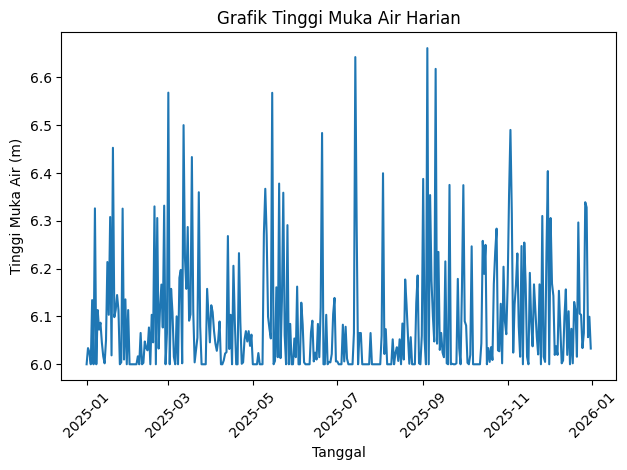

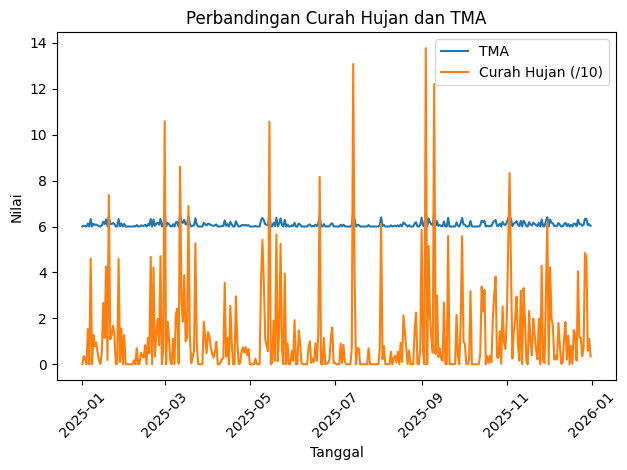

In [ ]:
import matplotlib.pyplot as plt

# Pastikan tanggal sudah datetime
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

plt.figure()
plt.plot(df['Tanggal'], df['TMA'])
plt.xlabel("Tanggal")
plt.ylabel("Tinggi Muka Air (m)")
plt.title("Grafik Tinggi Muka Air Harian")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()

# Plot TMA
plt.plot(df['Tanggal'], df['TMA'], label="TMA")

# Plot curah hujan (skala sekunder biar kebaca)
plt.plot(df['Tanggal'], df[kolom_ch]/10, label="Curah Hujan (/10)")

plt.xlabel("Tanggal")
plt.ylabel("Nilai")
plt.title("Perbandingan Curah Hujan dan TMA")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

##Analisis hidrologi

In [ ]:
# ANALISIS HIDROLOGI

def klasifikasi_kondisi(row):
    ch = row[kolom_ch]
    tma = row['TMA']

    # Kondisi kering
    if tma <= 4 and ch < 10:
        return "Kering"

    # Normal
    elif 4 < tma <= 7:
        return "Normal"

    # Waspada
    elif 7 < tma <= 10:
        return "Waspada"

    # Banjir
    else:
        return "Banjir"

# Terapkan klasifikasi
df['Status_Hidrologi'] = df.apply(klasifikasi_kondisi, axis=1)

#  HASIL
print("\n=== Analisis Hidrologi ===")
print(df[['Tanggal', kolom_ch, 'TMA', 'Status_Hidrologi']].head(15))

# 8. REKAP JUMLAH KONDISI
print("\n=== Rekap Kondisi ===")
print(df['Status_Hidrologi'].value_counts())




=== Analisis Hidrologi ===
      Tanggal  Curah_Hujan       TMA Status_Hidrologi
0  2025-01-01     0.000000  6.000000           Normal
1  2025-01-02     3.500000  6.033829           Normal
2  2025-01-03     2.600000  6.025347           Normal
3  2025-01-04     0.000000  6.000000           Normal
4  2025-01-05    15.400000  6.134250           Normal
5  2025-01-06     0.000000  6.000000           Normal
6  2025-01-07    46.000000  6.326163           Normal
7  2025-01-08     0.000000  6.000000           Normal
8  2025-01-09    12.733333  6.113435           Normal
9  2025-01-10     7.800000  6.072483           Normal
10 2025-01-11     9.500000  6.086977           Normal
11 2025-01-12     4.800000  6.045834           Normal
12 2025-01-13     1.700000  6.016717           Normal
13 2025-01-14     0.200000  6.001996           Normal
14 2025-01-15     5.300000  6.050375           Normal

=== Rekap Kondisi ===
Status_Hidrologi
Normal    365
Name: count, dtype: int64


##Interpretasi model hidrologi




In [ ]:
# INTERPRETASI MODEL HIDROLOGI

def interpretasi_model():

    print(" INTERPRETASI MODEL HIDROLOGI SEDERHANA \n")

    # -------------------------
    # 1. VARIABEL
    # -------------------------
    print("1. VARIABEL:")
    print("- Curah_Hujan (mm/hari): Input utama berupa jumlah hujan harian")
    print("- Tanggal: Dimensi waktu untuk analisis temporal")
    print("- TMA (meter): Output berupa tinggi muka air hasil model")
    print("- Status_Hidrologi: Klasifikasi kondisi air\n")


    # 2. PARAMETER

    print("2. PARAMETER MODEL:")
    print(f"- TMA_min = {TMA_min} m → batas minimum tinggi air")
    print(f"- TMA_max = {TMA_max} m → batas maksimum tinggi air")
    print(f"- TMA_normal = {TMA_normal} m → kondisi rata-rata")
    print(f"- koef_respon = {koef_respon} → sensitivitas terhadap hujan")
    print(f"- skala_hujan = {skala_hujan} mm → normalisasi curah hujan\n")


    # 3. PERSAMAAN MODEL

    print("3. PERSAMAAN MODEL:")
    print("TMA = TMA_normal + koef_respon × log(1 + Curah_Hujan / skala_hujan)\n")


    # 4. ASUMSI

    print("4. ASUMSI MODEL:")
    print("- Curah hujan adalah faktor utama yang mempengaruhi TMA")
    print("- Tidak mempertimbangkan evapotranspirasi dan infiltrasi")
    print("- Model bersifat harian dan tidak akumulatif")
    print("- Sistem DAS dan danau dianggap satu kesatuan")
    print("- Nilai TMA dibatasi antara 3–14 meter\n")


    # 5. INTERPRETASI HASIL

    print("5. INTERPRETASI HASIL:")
    print("- TMA rendah → kondisi kering")
    print("- TMA normal → kondisi stabil")
    print("- TMA tinggi → potensi banjir")
    print("- Respon TMA meningkat seiring curah hujan\n")


# PANGGIL FUNGSI
interpretasi_model()

=== INTERPRETASI MODEL HIDROLOGI SEDERHANA ===

1. VARIABEL:
- Curah_Hujan (mm/hari): Input utama berupa jumlah hujan harian
- Tanggal: Dimensi waktu untuk analisis temporal
- TMA (meter): Output berupa tinggi muka air hasil model
- Status_Hidrologi: Klasifikasi kondisi air

2. PARAMETER MODEL:
- TMA_min = 3 m → batas minimum tinggi air
- TMA_max = 14 m → batas maksimum tinggi air
- TMA_normal = 6 m → kondisi rata-rata
- koef_respon = 0.5 → sensitivitas terhadap hujan
- skala_hujan = 50 mm → normalisasi curah hujan

3. PERSAMAAN MODEL:
TMA = TMA_normal + koef_respon × log(1 + Curah_Hujan / skala_hujan)

4. ASUMSI MODEL:
- Curah hujan adalah faktor utama yang mempengaruhi TMA
- Tidak mempertimbangkan evapotranspirasi dan infiltrasi
- Model bersifat harian dan tidak akumulatif
- Sistem DAS dan danau dianggap satu kesatuan
- Nilai TMA dibatasi antara 3–14 meter

5. INTERPRETASI HASIL:
- TMA rendah → kondisi kering
- TMA normal → kondisi stabil
- TMA tinggi → potensi banjir
- Respon TMA me

##Interpretasi grafik model hidrologi

In [ ]:
# INTERPRETASI HIDROLOGI

def interpretasi_hidrologi(df):

    print("=== INTERPRETASI KONDISI HIDROLOGI ===\n")

    # 1. Statistik dasar

    ch_mean = df['Curah_Hujan'].mean()
    tma_mean = df['TMA'].mean()

    print(f"Rata-rata Curah Hujan : {ch_mean:.2f} mm/hari")
    print(f"Rata-rata TMA         : {tma_mean:.2f} m\n")

    # 2. Hubungan hujan vs TMA

    korelasi = df['Curah_Hujan'].corr(df['TMA'])

    print(f"Korelasi Hujan-TMA: {korelasi:.2f}")

    if korelasi > 0.7:
        print("Interpretasi: Hubungan KUAT → TMA sangat dipengaruhi hujan\n")
    elif korelasi > 0.4:
        print("Interpretasi: Hubungan SEDANG → hujan cukup berpengaruh\n")
    else:
        print("Interpretasi: Hubungan LEMAH → ada faktor lain berpengaruh\n")

    # 3. Respon hidrologi

    print("=== RESPON HIDROLOGI ===")

    hujan_tinggi = df[df['Curah_Hujan'] > df['Curah_Hujan'].quantile(0.75)]
    tma_tinggi = df[df['TMA'] > df['TMA'].quantile(0.75)]

    print(f"Hari hujan tinggi : {len(hujan_tinggi)} hari")
    print(f"Hari TMA tinggi   : {len(tma_tinggi)} hari")

    if len(tma_tinggi) > 0:
        print("Interpretasi: Terjadi peningkatan TMA saat hujan tinggi\n")

    # 4. Kondisi hidrologi

    print("=== KONDISI HIDROLOGI ===")

    kondisi = df['Status_Hidrologi'].value_counts()
    print(kondisi, "\n")

    if 'Banjir' in kondisi:
        print("Terdapat indikasi BANJIR pada beberapa periode")
    if 'Kering' in kondisi:
        print("Terdapat indikasi KEKERINGAN pada beberapa periode")
    if 'Normal' in kondisi:
        print("Sebagian besar kondisi NORMAL")

    # 5. Pola umum grafik

    print("\n=== POLA GRAFIK ===")
    print("- Saat curah hujan meningkat → TMA ikut naik")
    print("- Saat hujan rendah → TMA cenderung stabil/menurun")
    print("- Fluktuasi menunjukkan dinamika sistem DAS dan danau")

    # 6. Kesimpulan akhir

    print("\n=== KESIMPULAN ===")
    print("Kondisi hidrologi menunjukkan bahwa curah hujan")
    print("memiliki pengaruh terhadap tinggi muka air,")
    print("dengan respon yang bervariasi tergantung intensitas hujan.")
    print("Sistem DAS masih dalam batas normal jika TMA tidak")
    print("melewati ambang maksimum yang ditentukan.\n")


# PANGGIL FUNGSI

interpretasi_hidrologi(df)

=== INTERPRETASI KONDISI HIDROLOGI ===

Rata-rata Curah Hujan : 12.20 mm/hari
Rata-rata TMA         : 6.09 m

Korelasi Hujan-TMA: 0.98
Interpretasi: Hubungan KUAT → TMA sangat dipengaruhi hujan

=== RESPON HIDROLOGI ===
Hari hujan tinggi : 91 hari
Hari TMA tinggi   : 91 hari
Interpretasi: Terjadi peningkatan TMA saat hujan tinggi

=== KONDISI HIDROLOGI ===
Status_Hidrologi
Normal    365
Name: count, dtype: int64 

Sebagian besar kondisi NORMAL

=== POLA GRAFIK ===
- Saat curah hujan meningkat → TMA ikut naik
- Saat hujan rendah → TMA cenderung stabil/menurun
- Fluktuasi menunjukkan dinamika sistem DAS dan danau

=== KESIMPULAN ===
Kondisi hidrologi menunjukkan bahwa curah hujan
memiliki pengaruh terhadap tinggi muka air,
dengan respon yang bervariasi tergantung intensitas hujan.
Sistem DAS masih dalam batas normal jika TMA tidak
melewati ambang maksimum yang ditentukan.



##Visualisasi grafik

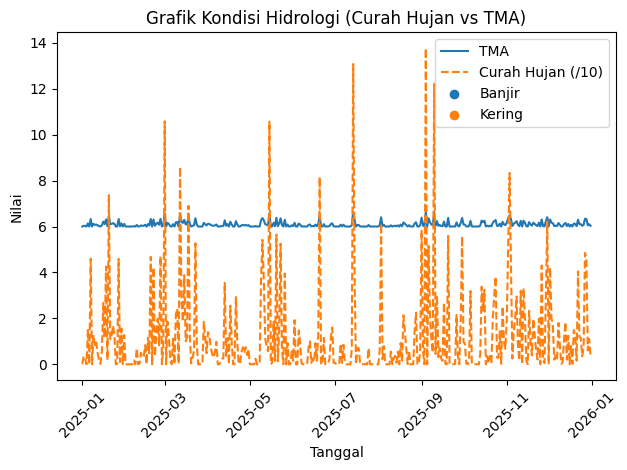

In [ ]:
import matplotlib.pyplot as plt

# Pastikan tanggal dalam format datetime
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

plt.figure()

# 1. Plot TMA

plt.plot(df['Tanggal'], df['TMA'], label='TMA')


# 2. Plot Curah Hujan (diskalakan)

plt.plot(df['Tanggal'], df['Curah_Hujan']/10, linestyle='--', label='Curah Hujan (/10)')


# 3. Tandai kondisi hidrologi

# Banjir
banjir = df[df['Status_Hidrologi'] == 'Banjir']
plt.scatter(banjir['Tanggal'], banjir['TMA'], label='Banjir')

# Kering
kering = df[df['Status_Hidrologi'] == 'Kering']
plt.scatter(kering['Tanggal'], kering['TMA'], label='Kering')

# 4. Label & tampilan

plt.xlabel("Tanggal")
plt.ylabel("Nilai")
plt.title("Grafik Kondisi Hidrologi (Curah Hujan vs TMA)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#Bagian 2

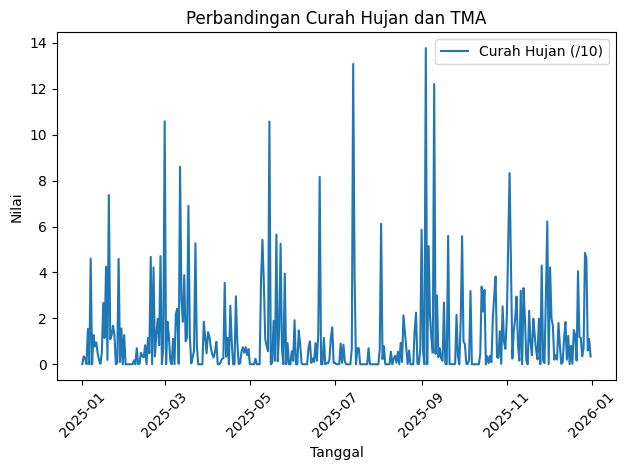

In [ ]:

# Plot curah hujan
plt.plot(df['Tanggal'], df[kolom_ch]/10, label="Curah Hujan (/10)")

plt.xlabel("Tanggal")
plt.ylabel("Nilai")
plt.title("Perbandingan Curah Hujan dan TMA")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

## INTERPRETASI VARIABEL & PARAMETER

In [ ]:
def interpretasi_variabel_parameter():

    print("=== INTERPRETASI VARIABEL DAN PARAMETER MODEL HIDROLOGI ===\n")


    # 1. VARIABEL

    print("1. VARIABEL:\n")

    print("Curah_Hujan (mm/hari):")
    print("- Input utama berupa jumlah hujan harian")
    print("- Berfungsi sebagai pemicu perubahan tinggi muka air\n")

    print("Tanggal:")
    print("- Menunjukkan urutan waktu (time series)")
    print("- Digunakan untuk analisis tren dan pola hidrologi\n")

    print("TMA (meter):")
    print("- Output model berupa tinggi muka air")
    print("- Menunjukkan respon sistem terhadap curah hujan\n")

    print("Status_Hidrologi:")
    print("- Klasifikasi kondisi air (Kering, Normal, Waspada, Banjir)")
    print("- Digunakan untuk interpretasi kondisi hidrologi\n")


    # 2. PARAMETER

    print("2. PARAMETER MODEL:\n")

    print(f"TMA_min = {TMA_min} m")
    print("- Batas minimum tinggi muka air (kondisi kering)\n")

    print(f"TMA_max = {TMA_max} m")
    print("- Batas maksimum tinggi muka air (kondisi banjir)\n")

    print(f"TMA_normal = {TMA_normal} m")
    print("- Nilai rata-rata atau kondisi normal sistem\n")

    print(f"koef_respon = {koef_respon}")
    print("- Menunjukkan sensitivitas TMA terhadap curah hujan")
    print("- Semakin besar → respon semakin cepat\n")

    print(f"skala_hujan = {skala_hujan} mm")
    print("- Parameter normalisasi curah hujan")
    print("- Mengontrol agar perubahan TMA tidak terlalu ekstrem\n")


    # 3. PERSAMAAN MODEL

    print("3. PERSAMAAN MODEL:\n")
    print("TMA = TMA_normal + koef_respon × log(1 + Curah_Hujan / skala_hujan)\n")

    # 4. INTERPRETASI MODEL

    print("4. INTERPRETASI MODEL:\n")
    print("- Curah hujan meningkatkan TMA secara non-linear")
    print("- Tidak semua hujan langsung menjadi kenaikan muka air")
    print("- Sistem memiliki batas minimum dan maksimum\n")


    # 5. MAKNA GRAFIK

    print("5. MAKNA DALAM GRAFIK:\n")
    print("- Garis TMA menunjukkan perubahan tinggi muka air")
    print("- Garis curah hujan menunjukkan pemicu perubahan")
    print("- Titik status menunjukkan kondisi ekstrem\n")


    # 6. KESIMPULAN

    print("6. KESIMPULAN:\n")
    print("Model ini menggambarkan hubungan antara curah hujan")
    print("dan tinggi muka air secara sederhana namun realistis.")
    print("Parameter yang digunakan mengontrol perilaku sistem")
    print("agar sesuai dengan kondisi hidrologi di lapangan.\n")



# PANGGIL FUNGSI

interpretasi_variabel_parameter()

=== INTERPRETASI VARIABEL DAN PARAMETER MODEL HIDROLOGI ===

1. VARIABEL:

Curah_Hujan (mm/hari):
- Input utama berupa jumlah hujan harian
- Berfungsi sebagai pemicu perubahan tinggi muka air

Tanggal:
- Menunjukkan urutan waktu (time series)
- Digunakan untuk analisis tren dan pola hidrologi

TMA (meter):
- Output model berupa tinggi muka air
- Menunjukkan respon sistem terhadap curah hujan

Status_Hidrologi:
- Klasifikasi kondisi air (Kering, Normal, Waspada, Banjir)
- Digunakan untuk interpretasi kondisi hidrologi

2. PARAMETER MODEL:

TMA_min = 3 m
- Batas minimum tinggi muka air (kondisi kering)

TMA_max = 14 m
- Batas maksimum tinggi muka air (kondisi banjir)

TMA_normal = 6 m
- Nilai rata-rata atau kondisi normal sistem

koef_respon = 0.5
- Menunjukkan sensitivitas TMA terhadap curah hujan
- Semakin besar → respon semakin cepat

skala_hujan = 50 mm
- Parameter normalisasi curah hujan
- Mengontrol agar perubahan TMA tidak terlalu ekstrem

3. PERSAMAAN MODEL:

TMA = TMA_normal + k

##Analisis hubungan curah hujan dengan kondisi DAS

In [ ]:
def analisis_hubungan_das(df):

    print("=== ANALISIS HUBUNGAN CURAH HUJAN DENGAN KONDISI DAS ===\n")


    # 1. Korelasi

    korelasi = df['Curah_Hujan'].corr(df['TMA'])
    print(f"Korelasi Curah Hujan vs TMA: {korelasi:.3f}")

    if korelasi > 0.7:
        print("Hubungan sangat kuat: perubahan hujan sangat mempengaruhi kondisi DAS\n")
    elif korelasi > 0.4:
        print("Hubungan sedang: hujan cukup mempengaruhi kondisi DAS\n")
    else:
        print("Hubungan lemah: terdapat faktor lain yang mempengaruhi DAS\n")


    # 2. Analisis perubahan (trend sederhana)

    df['Perubahan_Hujan'] = df['Curah_Hujan'].diff()
    df['Perubahan_TMA'] = df['TMA'].diff()

    print("=== ANALISIS PERUBAHAN HARIAN ===")

    # Hitung kesesuaian arah perubahan
    naik_bersamaan = ((df['Perubahan_Hujan'] > 0) & (df['Perubahan_TMA'] > 0)).sum()
    turun_bersamaan = ((df['Perubahan_Hujan'] < 0) & (df['Perubahan_TMA'] < 0)).sum()

    print(f"Hari hujan naik & TMA naik   : {naik_bersamaan}")
    print(f"Hari hujan turun & TMA turun : {turun_bersamaan}\n")


    # 3. Analisis kondisi DAS

    print("=== KONDISI DAS BERDASARKAN STATUS HIDROLOGI ===")
    kondisi = df['Status_Hidrologi'].value_counts()
    print(kondisi, "\n")


    # 4. Respon terhadap hujan tinggi

    hujan_tinggi = df['Curah_Hujan'] > df['Curah_Hujan'].quantile(0.75)
    tma_tinggi = df['TMA'] > df['TMA'].quantile(0.75)

    respon = (hujan_tinggi & tma_tinggi).sum()

    print(f"Jumlah hari hujan tinggi diikuti TMA tinggi: {respon}\n")

    # 5. Interpretasi

    print("=== INTERPRETASI ===")

    print("Perubahan curah hujan memiliki hubungan dengan kondisi DAS.")

    if korelasi > 0.5:
        print("- Ketika curah hujan meningkat, tinggi muka air cenderung ikut meningkat.")
        print("- Hal ini menunjukkan DAS memiliki respon yang cukup cepat terhadap hujan.")
    else:
        print("- Respon DAS terhadap hujan tidak terlalu kuat.")

    if respon > 0:
        print("- Pada beberapa kejadian, hujan tinggi menyebabkan peningkatan TMA yang signifikan.")
        print("- Ini mengindikasikan potensi genangan atau banjir.")

    print("- Fluktuasi TMA mencerminkan dinamika sistem hidrologi DAS.")
    print("- Kondisi DAS didominasi oleh:", kondisi.idxmax())

    print("\nKesimpulan:")
    print("Curah hujan merupakan faktor utama yang mempengaruhi kondisi DAS,")
    print("namun responnya dapat bervariasi tergantung karakteristik sistem.\n")


# PANGGIL FUNGSI

analisis_hubungan_das(df)

=== ANALISIS HUBUNGAN CURAH HUJAN DENGAN KONDISI DAS ===

Korelasi Curah Hujan vs TMA: 0.980
Hubungan sangat kuat: perubahan hujan sangat mempengaruhi kondisi DAS

=== ANALISIS PERUBAHAN HARIAN ===
Hari hujan naik & TMA naik   : 151
Hari hujan turun & TMA turun : 163

=== KONDISI DAS BERDASARKAN STATUS HIDROLOGI ===
Status_Hidrologi
Normal    365
Name: count, dtype: int64 

Jumlah hari hujan tinggi diikuti TMA tinggi: 91

=== INTERPRETASI ===
Perubahan curah hujan memiliki hubungan dengan kondisi DAS.
- Ketika curah hujan meningkat, tinggi muka air cenderung ikut meningkat.
- Hal ini menunjukkan DAS memiliki respon yang cukup cepat terhadap hujan.
- Pada beberapa kejadian, hujan tinggi menyebabkan peningkatan TMA yang signifikan.
- Ini mengindikasikan potensi genangan atau banjir.
- Fluktuasi TMA mencerminkan dinamika sistem hidrologi DAS.
- Kondisi DAS didominasi oleh: Normal

Kesimpulan:
Curah hujan merupakan faktor utama yang mempengaruhi kondisi DAS,
namun responnya dapat bervarias

#Bagian 3

##Analisis Skenario sederhana

In [ ]:
# PARAMETER MODEL (SAMA SEPERTI SEBELUMNYA)
TMA_min = 3
TMA_max = 14
TMA_normal = 6
koef_respon = 0.5
skala_hujan = 50

# FUNGSI HITUNG TMA

def hitung_tma(curah_hujan):
    tma = TMA_normal + koef_respon * np.log1p(curah_hujan / skala_hujan)
    return np.clip(tma, TMA_min, TMA_max)


# SIMULASI SKENARIO

def simulasi_skenario(df):

    print("=== SIMULASI PERUBAHAN CURAH HUJAN TERHADAP KONDISI DAS ===\n")

    # Skenario
    df['CH_Normal'] = df['Curah_Hujan']
    df['CH_Naik'] = df['Curah_Hujan'] * 1.5     # +50%
    df['CH_Turun'] = df['Curah_Hujan'] * 0.5    # -50%

    # Hitung TMA tiap skenario
    df['TMA_Normal'] = hitung_tma(df['CH_Normal'])
    df['TMA_Naik'] = hitung_tma(df['CH_Naik'])
    df['TMA_Turun'] = hitung_tma(df['CH_Turun'])


    # ANALISIS HASIL

    print("=== RATA-RATA TMA ===")
    print(f"Normal : {df['TMA_Normal'].mean():.2f} m")
    print(f"Naik   : {df['TMA_Naik'].mean():.2f} m")
    print(f"Turun  : {df['TMA_Turun'].mean():.2f} m\n")

    # Hitung perubahan
    delta_naik = df['TMA_Naik'].mean() - df['TMA_Normal'].mean()
    delta_turun = df['TMA_Normal'].mean() - df['TMA_Turun'].mean()

    print("=== PERUBAHAN TMA ===")
    print(f"Kenaikan hujan → TMA naik sebesar {delta_naik:.2f} m")
    print(f"Penurunan hujan → TMA turun sebesar {delta_turun:.2f} m\n")


    # INTERPRETASI LINGKUNGAN

    print("=== IMPLIKASI LINGKUNGAN ===\n")

    # Skenario naik
    print("1. Jika curah hujan meningkat:")
    print("- Terjadi peningkatan tinggi muka air")
    print("- Potensi banjir dan genangan meningkat")
    print("- Risiko erosi dan limpasan permukaan bertambah")
    print("- Ekosistem rawa/danau cenderung meluas\n")

    # Skenario turun
    print("2. Jika curah hujan menurun:")
    print("- Tinggi muka air menurun")
    print("- Potensi kekeringan meningkat")
    print("- Ketersediaan air untuk ekosistem berkurang")
    print("- Risiko kebakaran lahan (terutama gambut) meningkat\n")

    # Berbasis data
    print("=== INTERPRETASI BERBASIS DATA ===")
    print("Hasil simulasi menunjukkan bahwa perubahan curah hujan")
    print("berbanding lurus dengan perubahan tinggi muka air.")
    print("Namun, perubahan tersebut tidak linear karena dipengaruhi")
    print("oleh fungsi logaritmik dalam model.\n")

    print("Kesimpulan:")
    print("DAS sangat sensitif terhadap perubahan curah hujan,")
    print("sehingga perubahan kecil dalam hujan dapat berdampak")
    print("signifikan terhadap kondisi hidrologi.\n")



# JALANKAN SIMULASI
simulasi_skenario(df)

=== SIMULASI PERUBAHAN CURAH HUJAN TERHADAP KONDISI DAS ===

=== RATA-RATA TMA ===
Normal : 6.09 m
Naik   : 6.12 m
Turun  : 6.05 m

=== PERUBAHAN TMA ===
Kenaikan hujan → TMA naik sebesar 0.03 m
Penurunan hujan → TMA turun sebesar 0.04 m

=== IMPLIKASI LINGKUNGAN ===

1. Jika curah hujan meningkat:
- Terjadi peningkatan tinggi muka air
- Potensi banjir dan genangan meningkat
- Risiko erosi dan limpasan permukaan bertambah
- Ekosistem rawa/danau cenderung meluas

2. Jika curah hujan menurun:
- Tinggi muka air menurun
- Potensi kekeringan meningkat
- Ketersediaan air untuk ekosistem berkurang
- Risiko kebakaran lahan (terutama gambut) meningkat

=== INTERPRETASI BERBASIS DATA ===
Hasil simulasi menunjukkan bahwa perubahan curah hujan
berbanding lurus dengan perubahan tinggi muka air.
Namun, perubahan tersebut tidak linear karena dipengaruhi
oleh fungsi logaritmik dalam model.

Kesimpulan:
DAS sangat sensitif terhadap perubahan curah hujan,
sehingga perubahan kecil dalam hujan dapat berda